CORRELATION ANALYSIS

In [3]:
import pandas as pd

# Create a DataFrame with sample data
data = pd.DataFrame({'X': [1, 2, 3, 4, 5], 'Y': [1,2,3,4,5]})

# Calculate correlation coefficient
correlation_coefficient = data['X'].corr(data['Y'])

print("Correlation Coefficient:", correlation_coefficient)


Correlation Coefficient: 0.9999999999999999


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
columns = pd.read_csv("diabetes.csv");
columns.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [4]:
data={
    'x':[1,2,3,4,5],
    'y':[2,4,6,8,10]
}
c=pd.DataFrame(data);
print(c.corr())

     x    y
x  1.0  1.0
y  1.0  1.0


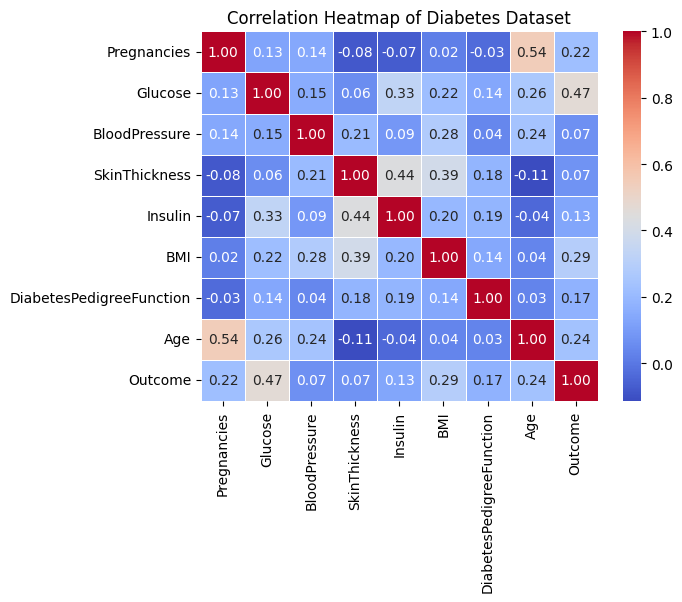

In [5]:
correlation_matrix = columns.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Diabetes Dataset')
plt.show()

In [12]:
columns[['Age','BMI']].corr(method='kendall')

,Age,BMI
Age,1.000000,0.088678
BMI,0.088678,1.000000


In [14]:
import numpy as np
print(np.corrcoef(columns['Outcome'],columns['Age']))

[[1.         0.23835598]
 [0.23835598 1.        ]]


SCATTER PLOTS

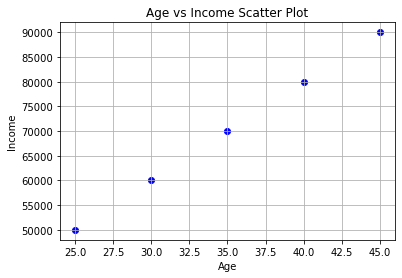

In [15]:
import matplotlib.pyplot as plt

# Sample Data
age = [25, 30, 35, 40, 45]
income = [50000, 60000, 70000, 80000, 90000]

# Create Scatter Plot
plt.scatter(age, income, color='blue', marker='o')

# Add Labels and Title
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income Scatter Plot')

# Show Grid
plt.grid(True)

# Display Plot
plt.show()


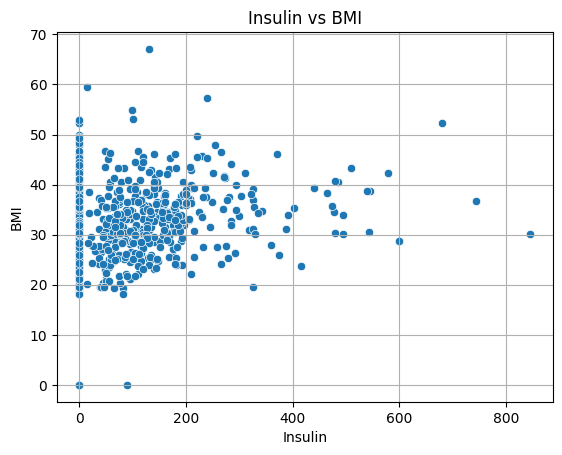

In [28]:
plt.scatter(columns['Insulin'],columns['BMI'],color='red',marker='')
plt.xlabel('Insulin')
plt.ylabel('BMI')
plt.title('Insulin vs BMI')
sns.scatterplot(x='Insulin',y='BMI',data=df)
plt.grid(True)

plt.show()

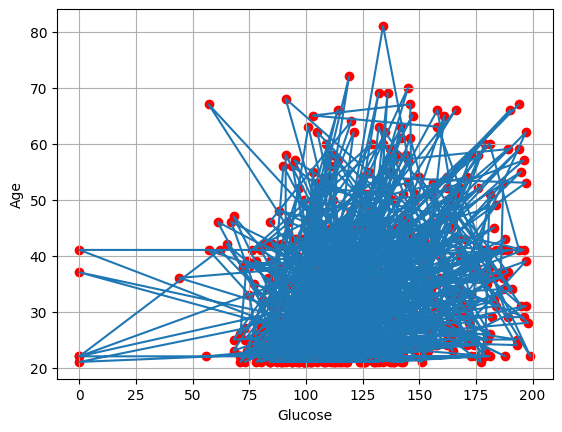

In [23]:
plt.scatter(columns['Glucose'],columns['Age'],color='red',marker='o')

plt.xlabel('Glucose')
plt.ylabel('Age')

plt.plot(columns['Glucose'],columns['Age'])
plt.grid(True)

plt.show()

CROSS TABULATION

In [39]:
import pandas as pd

# Sample Data
data = {
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male'],
    'Purchase': ['Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(data)

# Cross Tabulation
crosstab = pd.crosstab(df['Gender'], df['Purchase'])
print(crosstab)

Purchase  No  Yes
Gender           
Female     2    2
Male       1    3


In [18]:
columns['age_bin']=pd.cut(columns['Age'],bins=3,labels=['21-41','41-61','61-81'])
pd.crosstab(columns['Glucose'],columns['age_bin'])

age_bin,21-41,41-61,61-81
Glucose,,,
0,5,0,0
44,1,0,0
56,1,0,0
57,1,0,1
61,0,1,0
...,...,...,...
195,1,1,0
196,2,1,0
197,2,1,1


In [42]:
columns.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,age_bin
351,4,137,84,0,0,31.2,0.252,30,0,21-41
729,2,92,52,0,0,30.1,0.141,22,0,21-41
347,3,116,0,0,0,23.5,0.187,23,0,21-41
489,8,194,80,0,0,26.1,0.551,67,0,61-81
507,1,130,60,23,170,28.6,0.692,21,0,21-41


BIVARIANT REGRESSION (LINEAR)

Mean Squared Error: 930.1598561894372
R-squared: 0.07567172141031409


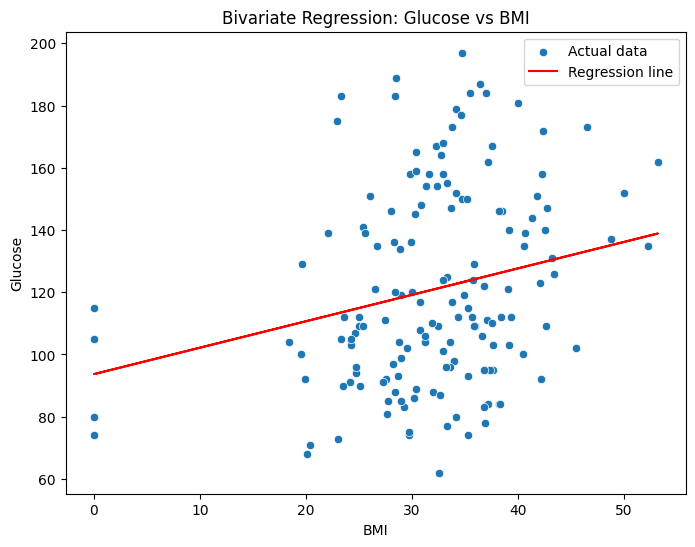

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load your dataset (replace 'your_dataset.csv' with your actual file path)


# Select the independent and dependent variables
X = df[['BMI']]  # Independent variable
y = df['Glucose']  # Dependent variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Plotting the regression line with the data
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test['BMI'], y=y_test, label='Actual data')
plt.plot(X_test['BMI'], y_pred, color='red', label='Regression line')
plt.title('Bivariate Regression: Glucose vs BMI')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.legend()
plt.show()




Accuracy: 0.6558441558441559
Confusion Matrix:
[[88 11]
 [42 13]]
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.89      0.77        99
           1       0.54      0.24      0.33        55

    accuracy                           0.66       154
   macro avg       0.61      0.56      0.55       154
weighted avg       0.63      0.66      0.61       154



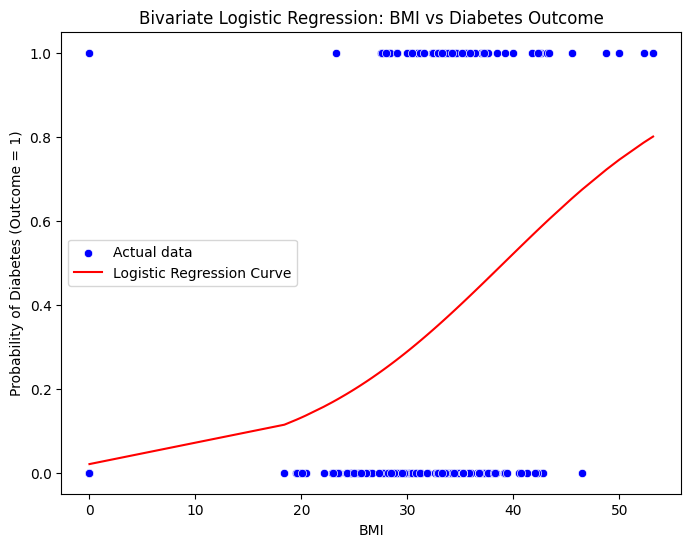

In [19]:
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print the results
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{class_report}')

# Plotting the logistic regression curve
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test['BMI'], y=y_test, label='Actual data', color='blue')
sns.lineplot(x=X_test['BMI'], y=model.predict_proba(X_test)[:, 1], color='red', label='Logistic Regression Curve')
plt.title('Bivariate Logistic Regression: BMI vs Diabetes Outcome')
plt.xlabel('BMI')
plt.ylabel('Probability of Diabetes (Outcome = 1)')
plt.legend()
plt.show()